In [7]:
from DiffusionRWR_model_package.data_sorting import load_and_process_modelled_data
import pandas as pd

datasets = load_and_process_modelled_data(histone_dataset_filter="all")

Number of CSV files found: 4

CSV files found:
  - overlap_filtered_k20me3_m_v2.csv
  - overlap_filtered_k27me3_m_v2.csv
  - overlap_filtered_k9me2_m_v2.csv
  - overlap_filtered_rna_ai_m_v2.csv
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k20me3_m_v2' with shape: (657, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k27me3_m_v2' with shape: (650, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k9me2_m_v2' with shape: (1001, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_rna_ai_m_v2' with shape: (384, 5) (row-wise standardized)

Successfully imported 4 datasets.
Available datasets: ['overlap_filtered_k20me3_m_v2', 'overlap_filtered_k27me3_m_v2', 'overlap_filtered_k9me2_m_v2', 'overlap_filtered_rna_ai_m_v2']


In [2]:
# Order is rna, k9me2, k20me3, k27me3
sigma_exp = [0.0125, 0.005, 0.0075, 0.0025]
sigma_gaussian = [0.015, 0.005, 0.0125, 0.0075]
lambda_reg = [0.2, 0.3, 0.3, 0.3]
keys = ["rna_ai", "k9me2", "k20me3", "k27me3"]


In [3]:
import importlib
import DiffusionRWR_model_package.graph_generation.generate_graph_internal as generate_graph_internal
from DiffusionRWR_model_package.graph_generation.edge_weight_functions import cor_exponential_abs, cor_gaussian_abs

importlib.reload(generate_graph_internal)
generate_single_layer_graphs = generate_graph_internal.generate_single_layer_graphs

keys = ["rna_ai", "k9me2", "k20me3", "k27me3"]

single_layer_graphs_exp = {}
single_layer_signs_exp = {}
for k, s in zip(keys, sigma_exp):
    print(f"Generating EXP single layer graph for {k} with sigma={s}...")
    adjacency_dict, sign_dict = generate_single_layer_graphs(
        {k: datasets[k]},
        (lambda d, sigma=s: cor_exponential_abs(d, sigma=sigma)),
        start="e4",
        end=None,
        return_signs=True,
        threshold=0.01,
    )
    single_layer_graphs_exp.update(adjacency_dict)
    single_layer_signs_exp.update(sign_dict)

single_layer_graphs_gaussian = {}
single_layer_signs_gaussian = {}
for k, s in zip(keys, sigma_gaussian):
    print(f"Generating GAUSSIAN single layer graph for {k} with sigma={s}...")
    adjacency_dict, sign_dict = generate_single_layer_graphs(
        {k: datasets[k]},
        (lambda d, sigma=s: cor_gaussian_abs(d, sigma=sigma)),
        start=None,
        end=None,
        return_signs=True,
        threshold=0.01,
    )
    single_layer_graphs_gaussian.update(adjacency_dict)
    single_layer_signs_gaussian.update(sign_dict)

Generating EXP single layer graph for rna_ai with sigma=0.0125...

Generating single-layer graph using edge function: <lambda>

--- Processing dataset: rna_ai ---
Data columns: ['0', '1', '2', '3', '4']
Basis vector e1: [ 2.  -0.5 -0.5 -0.5 -0.5]
Basis vector e2: [-0.5  2.  -0.5 -0.5 -0.5]
Basis vector e3: [-0.5 -0.5  2.  -0.5 -0.5]
Basis vector e4: [-0.5 -0.5 -0.5  2.  -0.5]
Basis vector e5: [-0.5 -0.5 -0.5 -0.5  2. ]
Data shape with basis vectors: (389, 5) (384 genes + 5 basis vectors)

Removing edges for basis vector: e1

Removing edges for basis vector: e2

Removing edges for basis vector: e3

Removing edges for basis vector: e5
Adjacency matrix shape: (389, 389)

Adjacency matrix statistics (<lambda>):
  Min: 0.000000
  Max: 0.999370
  Mean: 0.028144
  Median: 0.000000
Generating EXP single layer graph for k9me2 with sigma=0.005...

Generating single-layer graph using edge function: <lambda>

--- Processing dataset: k9me2 ---
Data columns: ['0', '1', '2', '3', '4']
Basis vector e1

In [4]:
import importlib
import numpy as np
import DiffusionRWR_model_package.graph_generation.generate_graph_internal as generate_graph_internal

importlib.reload(generate_graph_internal)
lasso_single_graph = generate_graph_internal.lasso_single_graph


def _build_standard_basis_map(n_features):
    standard_basis = np.eye(n_features)
    standard_basis_std = np.zeros_like(standard_basis)
    for i in range(n_features):
        row_mean = standard_basis[i].mean()
        row_std = standard_basis[i].std()
        if row_std == 0:
            standard_basis_std[i] = standard_basis[i] - row_mean
        else:
            standard_basis_std[i] = (standard_basis[i] - row_mean) / row_std
    return {f"e{i + 1}": standard_basis_std[i] for i in range(n_features)}


def set_spd_basis_connections(
    spd_graphs,
    spd_signs,
    data_dict,
    basis_nodes=("e3", "e5"),
    top_k=3,
    edge_weight=1.0,
    action="add",
):
    if action not in {"add", "remove"}:
        raise ValueError("action must be 'add' or 'remove'")

    updated_graphs = {k: df.copy() for k, df in spd_graphs.items()}
    updated_signs = {k: df.copy() for k, df in spd_signs.items()}

    for layer_name in updated_graphs:
        adj = updated_graphs[layer_name]
        sign = updated_signs[layer_name]

        if action == "remove":
            for basis_name in basis_nodes:
                if basis_name in adj.index:
                    adj = adj.drop(index=basis_name, columns=basis_name)
                if basis_name in sign.index:
                    sign = sign.drop(index=basis_name, columns=basis_name)

            adj = adj.sort_index().sort_index(axis=1)
            sign = sign.reindex(index=adj.index, columns=adj.columns).fillna(0).astype(int)

            updated_graphs[layer_name] = adj
            updated_signs[layer_name] = sign
            continue

        layer_data = data_dict[layer_name]
        basis_map = _build_standard_basis_map(int(layer_data.shape[1]))
        candidate_nodes = [n for n in adj.index if n in layer_data.index and str(n) not in basis_map]

        for basis_name in basis_nodes:
            if basis_name not in basis_map:
                continue

            basis_vec = basis_map[basis_name]
            corr_scores = {}
            for node in candidate_nodes:
                corr = np.corrcoef(layer_data.loc[node].to_numpy(dtype=float), basis_vec)[0, 1]
                if np.isfinite(corr):
                    corr_scores[node] = float(corr)

            top_nodes = sorted(corr_scores, key=corr_scores.get, reverse=True)[: int(top_k)]

            if basis_name not in adj.index:
                adj.loc[basis_name] = 0.0
                adj[basis_name] = 0.0
                sign.loc[basis_name] = 0
                sign[basis_name] = 0

            adj.loc[basis_name, :] = 0.0
            adj.loc[:, basis_name] = 0.0
            sign.loc[basis_name, :] = 0
            sign.loc[:, basis_name] = 0

            for node in top_nodes:
                edge_sign = 1 if corr_scores[node] >= 0 else -1
                adj.loc[basis_name, node] = float(edge_weight)
                adj.loc[node, basis_name] = float(edge_weight)
                sign.loc[basis_name, node] = edge_sign
                sign.loc[node, basis_name] = edge_sign

            print(f"{layer_name} | {basis_name}: attached to {top_nodes}")

        adj = adj.sort_index().sort_index(axis=1)
        sign = sign.reindex(index=adj.index, columns=adj.columns).fillna(0).astype(int)

        updated_graphs[layer_name] = adj
        updated_signs[layer_name] = sign

    return updated_graphs, updated_signs


single_layer_graphs_spd = {}
single_layer_signs_spd = {}
basis_nodes = {"e3", "e5"}
for k, lam in zip(keys, lambda_reg):
    print(f"Generating SPD-Lasso single layer graph for {k} with lambda={lam}...")
    adjacency_dict, sign_dict = lasso_single_graph(
        {k: datasets[k]},
        edge_fn=None,
        start="e3",
        end="e5",
        return_signs=True,
        lasso_lambda=lam,
        threshold=0.01,
    )
    present_basis = sorted(set(adjacency_dict[k].index) & basis_nodes)
    print(f"Basis nodes present in raw {k}: {present_basis}")
    single_layer_graphs_spd.update(adjacency_dict)
    single_layer_signs_spd.update(sign_dict)

single_layer_graphs_spd_base = {k: df.copy() for k, df in single_layer_graphs_spd.items()}
single_layer_signs_spd_base = {k: df.copy() for k, df in single_layer_signs_spd.items()}

print("SPD base graphs built without basis nodes.")
print("Use set_spd_basis_connections(...) in a lightweight cell to add/remove e3/e5 without rerunning lasso.")

Generating SPD-Lasso single layer graph for rna_ai with lambda=0.2...

Generating single-layer graph using SPD-Lasso (numba) edge construction
SPD-Lasso regularization lambda: 0.2
SPD-Lasso regularization gamma: 0.02
SPD-Lasso regularization eta: 20

--- Processing dataset: rna_ai ---
Data shape (genes x time): (384, 5)
starting proximal solver...
Highest number of outgoing edges: 169 (nodes: e3)
Lowest number of outgoing edges: 0 (nodes: BFSP2)
Highest number of incoming edges: 169 (nodes: e3)
Lowest number of incoming edges: 0 (nodes: BFSP2)
Adjacency matrix shape: (389, 389)
SPD-Lasso regularization lambda: 0.2
Basis nodes present in raw rna_ai: ['e3', 'e5']
Generating SPD-Lasso single layer graph for k9me2 with lambda=0.3...

Generating single-layer graph using SPD-Lasso (numba) edge construction
SPD-Lasso regularization lambda: 0.3
SPD-Lasso regularization gamma: 0.02
SPD-Lasso regularization eta: 20

--- Processing dataset: k9me2 ---
Data shape (genes x time): (1001, 5)
starting 

In [13]:
# Toggle e3/e5 basis connections on already-built SPD graphs (no lasso rerun).
spd_basis_action = "add"  # "add" or "remove"
spd_basis_nodes = ("e3","e5")
spd_basis_top_k = 1
spd_basis_edge_weight = 1.0

single_layer_graphs_spd, single_layer_signs_spd = set_spd_basis_connections(
    spd_graphs=single_layer_graphs_spd_base,
    spd_signs=single_layer_signs_spd_base,
    data_dict={k: datasets[k] for k in keys},
    basis_nodes=spd_basis_nodes,
    top_k=spd_basis_top_k,
    edge_weight=spd_basis_edge_weight,
    action=spd_basis_action,
)

for k in keys:
    present_basis = sorted(set(single_layer_graphs_spd[k].index) & set(spd_basis_nodes))
    print(f"{k}: basis present -> {present_basis}")

rna_ai | e3: attached to ['ARHGAP6']
rna_ai | e5: attached to ['GPX3']
k9me2 | e3: attached to ['SLC8A1*10']
k9me2 | e5: attached to ['PLCL1*9']
k20me3 | e3: attached to ['CENPF*16']
k20me3 | e5: attached to ['AKAP1*43']
k27me3 | e3: attached to ['PSMA1*6']
k27me3 | e5: attached to ['FST*18']
rna_ai: basis present -> ['e3', 'e5']
k9me2: basis present -> ['e3', 'e5']
k20me3: basis present -> ['e3', 'e5']
k27me3: basis present -> ['e3', 'e5']


In [19]:
from DiffusionRWR_model_package.graph_generation.generate_multi_graph import create_shadow_network_multigraph
from DiffusionRWR_model_package.graph_generation.edge_weight_functions import cor_abs_inter

def build_shadow_multigraph(intra_graphs, sign_matrices):
    missing = [k for k in keys if k not in intra_graphs or k not in sign_matrices]
    if missing:
        raise ValueError(f"Missing layers for shadow multigraph: {missing}")
    return create_shadow_network_multigraph(
        std_data_dict=datasets,
        intra_graphs={k: intra_graphs[k] for k in keys},
        sign_matrices={k: sign_matrices[k] for k in keys},
        edge_fn_inter=cor_abs_inter,
        start="e4",
        end= None,
        alpha=0.5,
        gamma=0.5,
    )

shadow_multigraph_exp = build_shadow_multigraph(single_layer_graphs_exp, single_layer_signs_exp)
shadow_multigraph_gaussian = build_shadow_multigraph(single_layer_graphs_gaussian, single_layer_signs_gaussian)
shadow_multigraph_spd = build_shadow_multigraph(single_layer_graphs_spd, single_layer_signs_spd)

CREATING SHADOW NETWORK (BLOCKWISE CONSTRUCTION)
Building normalized regular multigraph, then applying sign masks blockwise
Note: gamma=0.5 is ignored in dynamic-shadow mode
Alpha (inter-layer transition probability): 0.5
Intra-layer probability: 0.5

[STEP 1] Building normalized regular multigraph...
CREATING MULTI-LAYER GRAPH WITH LAYER TRANSITIONS
Alpha (inter-layer transition probability): 0.5
Intra-layer probability: 0.5
CREATING MULTI-LAYER GRAPH

[STEP 1] Intra layer graphs are generated separately and provided as input (skipping generation here)

[STEP 2] Generating inter-layer connections...

  Connecting k20me3 -> k27me3
    Section shape: (657, 650)

  Connecting k20me3 -> k9me2
    Section shape: (657, 1001)

  Connecting k20me3 -> rna_ai
    Section shape: (657, 384)

  Connecting k27me3 -> k9me2
    Section shape: (650, 1001)

  Connecting k27me3 -> rna_ai
    Section shape: (650, 384)

  Connecting k9me2 -> rna_ai
    Section shape: (1001, 384)

[STEP 3] Assembling compl

In [70]:
import networkx as nx
import pandas as pd

shadow_graphs = {
    "exp": shadow_multigraph_exp,
    "gaussian": shadow_multigraph_gaussian,
    "spd": shadow_multigraph_spd,
}

def drop_neg_suffix(series):
    return series[~series.index.to_series().astype(str).str.endswith("neg")]

def compute_centralities(adj_df):
    G = nx.from_pandas_adjacency(adj_df, create_using=nx.DiGraph)

    pagerank = nx.pagerank(G, weight="weight")

    try:
        eigenvector = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-06, weight="weight")
    except Exception:
        eigenvector = nx.eigenvector_centrality(G.to_undirected(), max_iter=1000, tol=1e-06, weight="weight")

    pagerank_series = pd.Series(pagerank, name="pagerank").sort_values(ascending=False)
    eigenvector_series = pd.Series(eigenvector, name="eigenvector").sort_values(ascending=False)

    pagerank_series = drop_neg_suffix(pagerank_series)
    eigenvector_series = drop_neg_suffix(eigenvector_series)
    return pagerank_series, eigenvector_series

centrality_scores = {}
for name, adj in shadow_graphs.items():
    pagerank_series, eigenvector_series = compute_centralities(adj)
    centrality_scores[name] = {
        "pagerank": pagerank_series,
        "eigenvector": eigenvector_series,
    }

    top_pr = pagerank_series.head(20)
    top_ev = eigenvector_series.head(20)

    print(f"\n=== {name.upper()} shadow multigraph ===")
    print("\nTop 20 PageRank (excluding *_neg)")
    print(top_pr.to_frame())
    print("\nTop 20 Eigenvector Centrality (excluding *_neg)")
    print(top_ev.to_frame())


=== EXP shadow multigraph ===

Top 20 PageRank (excluding *_neg)
                 pagerank
SHOX2_rna_ai     0.000972
FMNL2*2_k20me3   0.000897
TMEM164_rna_ai   0.000809
DNAH14_rna_ai    0.000684
SGMS1_rna_ai     0.000638
FHOD3_rna_ai     0.000638
FHOD3*48_k20me3  0.000569
HK1_rna_ai       0.000552
GRIK2_rna_ai     0.000547
AR*5_k20me3      0.000534
SGMS1*1_k27me3   0.000524
CDKN3_rna_ai     0.000518
ANK3_rna_ai      0.000508
AR*21_k20me3     0.000497
SEMA5A_rna_ai    0.000473
PDZD2_rna_ai     0.000469
SATB1_rna_ai     0.000459
PLCL1*14_k27me3  0.000458
TBC1D2_rna_ai    0.000455
RNF180_rna_ai    0.000455

Top 20 Eigenvector Centrality (excluding *_neg)
                  eigenvector
SHOX2_rna_ai         0.075461
TMEM164_rna_ai       0.061527
FMNL2*2_k20me3       0.060391
DNAH14_rna_ai        0.051229
FHOD3_rna_ai         0.049116
SGMS1_rna_ai         0.047850
FHOD3*48_k20me3      0.041473
HK1_rna_ai           0.040126
GRIK2_rna_ai         0.039963
AR*5_k20me3          0.037493
SGMS1*1_k

In [71]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.decomposition import PCA


def build_pca_projection_map(data_dict, keys):
    combined_data = pd.concat([data_dict[k] for k in keys], axis=0)
    pca_model = PCA(n_components=3, random_state=42)
    combined_embedding = pca_model.fit_transform(combined_data)

    node_to_coords = {}
    start_idx = 0
    for k in keys:
        cat_df = data_dict[k]
        end_idx = start_idx + len(cat_df)
        cat_embedding = combined_embedding[start_idx:end_idx]
        for gene, coords in zip(cat_df.index, cat_embedding):
            node_to_coords[f"{gene}_{k}"] = coords
        start_idx = end_idx

    # Include basis vectors in PCA space for optional plotting
    standard_basis = np.eye(5)
    standard_basis_std = np.zeros_like(standard_basis)
    for i in range(5):
        row_mean = standard_basis[i].mean()
        row_std = standard_basis[i].std()
        if row_std == 0:
            standard_basis_std[i] = standard_basis[i] - row_mean
        else:
            standard_basis_std[i] = (standard_basis[i] - row_mean) / row_std

    basis_df = pd.DataFrame(standard_basis_std, columns=combined_data.columns)
    basis_coords = pca_model.transform(basis_df)
    for i, b in enumerate(["e1", "e2", "e3", "e4", "e5"]):
        node_to_coords[b] = basis_coords[i]

    return pca_model, node_to_coords


def plot_node_scores_on_pca(
    score_series,
    node_to_coords,
    pca_model,
    keys,
    title="3D PCA node scores",
    dataset_color_map=None,
    size_range=(6.0, 34.0),
    alpha_range=(0.20, 1.00),
    basis_size=14.0,
    basis_alpha=0.95,
    show=True,
    scale_mode="relative",
    score_reference=None,
    highlight_source_near_one=False,
    source_tolerance=0.02,
    source_size_multiplier=1.15,
    source_outline_color="#FFD700",
    source_legend_label=None,
):
    if dataset_color_map is None:
        dataset_color_map = {
            "rna_ai": "#1f77b4",
            "k9me2": "#ff7f0e",
            "k20me3": "#2ca02c",
            "k27me3": "#d62728",
            "basis": "#7f7f7f",
            "other": "#9467bd",
        }

    def infer_dataset(node_name):
        for dataset_name in sorted(keys, key=len, reverse=True):
            if str(node_name).endswith(f"_{dataset_name}"):
                return dataset_name
        if node_name in {"e1", "e2", "e3", "e4", "e5"}:
            return "basis"
        return "other"

    def hex_to_rgb(hex_color):
        h = hex_color.lstrip("#")
        return int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)

    score_series = pd.Series(score_series, dtype=float).dropna()
    score_series = score_series[np.isfinite(score_series.values)]
    score_series = score_series[score_series.index.isin(node_to_coords.keys())]

    if score_series.empty:
        raise ValueError("No score nodes matched PCA coordinates.")

    size_min, size_max = size_range
    radius_min, radius_max = size_min / 2.0, size_max / 2.0
    alpha_min, alpha_max = alpha_range

    node_datasets = pd.Series([infer_dataset(node) for node in score_series.index], index=score_series.index)
    basis_mask = node_datasets == "basis"
    non_basis_scores = score_series[~basis_mask]
    source_mask = pd.Series(False, index=score_series.index)
    if highlight_source_near_one and not non_basis_scores.empty:
        tol = float(source_tolerance)
        if tol < 0.0 or tol >= 1.0:
            raise ValueError("source_tolerance must be in [0, 1)")
        lower = 1.0 - tol
        upper = 1.0 + tol
        source_mask.loc[non_basis_scores.index] = (non_basis_scores >= lower) & (non_basis_scores <= upper)

    # Score scaling for non-basis nodes.
    # relative: min-max within current series (default).
    # absolute: divide sqrt(score) by fixed score_reference (for r-sweep comparability).
    score_norm = pd.Series(0.5, index=score_series.index, dtype=float)
    non_basis_for_scale = non_basis_scores[~source_mask.loc[non_basis_scores.index]]
    if not non_basis_for_scale.empty:
        transformed = pd.Series(
            np.sqrt(np.clip(non_basis_for_scale.to_numpy(dtype=float), a_min=0.0, a_max=None)),
            index=non_basis_for_scale.index,
        )
        if scale_mode == "relative":
            tmin = transformed.min()
            tmax = transformed.max()
            if np.isclose(tmax, tmin):
                score_norm.loc[transformed.index] = 0.5
            else:
                score_norm.loc[transformed.index] = (transformed - tmin) / (tmax - tmin)
        elif scale_mode == "absolute":
            if score_reference is None:
                raise ValueError("score_reference must be provided when scale_mode='absolute'")
            ref = float(score_reference)
            if (not np.isfinite(ref)) or ref <= 0.0:
                raise ValueError("score_reference must be a positive finite float")
            score_norm.loc[transformed.index] = np.clip(transformed / ref, 0.0, 1.0)
        else:
            raise ValueError("scale_mode must be either 'relative' or 'absolute'")

    if source_mask.any():
        score_norm.loc[source_mask] = 1.0

    fig = go.Figure()
    plot_order = [k for k in keys if k in node_datasets.values] + ["basis", "other"]

    for dataset_name in plot_order:
        dataset_nodes = node_datasets[node_datasets == dataset_name].index
        if len(dataset_nodes) == 0:
            continue

        dataset_scores = score_series.loc[dataset_nodes]
        dataset_coords = np.array([node_to_coords[node] for node in dataset_nodes])

        if dataset_name == "basis":
            marker_radii = np.full(len(dataset_nodes), basis_size / 2.0)
            marker_alphas = np.full(len(dataset_nodes), basis_alpha)
            marker_symbol = "diamond"
        else:
            dataset_norm = score_norm.loc[dataset_nodes].values
            marker_radii = radius_min + (radius_max - radius_min) * dataset_norm
            marker_alphas = alpha_min + (alpha_max - alpha_min) * dataset_norm
            marker_symbol = "circle"

        marker_sizes = 2.0 * marker_radii

        r, g, b = hex_to_rgb(dataset_color_map.get(dataset_name, dataset_color_map["other"]))
        marker_colors = [f"rgba({r},{g},{b},{alpha:.3f})" for alpha in marker_alphas]

        fig.add_trace(
            go.Scatter3d(
                x=dataset_coords[:, 0],
                y=dataset_coords[:, 1],
                z=dataset_coords[:, 2],
                mode="markers",
                name=dataset_name,
                marker=dict(
                    size=marker_sizes,
                    color=marker_colors,
                    symbol=marker_symbol,
                    line=dict(width=0.3, color="black"),
                ),
                text=[
                    f"{node}<br>Dataset: {dataset_name}<br>Score: {score:.6g}<br>Radius(px): {radius:.3f}<br>Opacity: {alpha:.3f}"
                    for node, score, radius, alpha in zip(dataset_nodes, dataset_scores.values, marker_radii, marker_alphas)
                ],
                hovertemplate="%{text}<extra></extra>",
            )
        )

    if highlight_source_near_one and source_mask.any():
        source_nodes = source_mask[source_mask].index
        source_coords = np.array([node_to_coords[node] for node in source_nodes])
        source_scores = score_series.loc[source_nodes]
        source_sizes = np.full(len(source_nodes), size_max * float(source_size_multiplier))
        source_label = source_legend_label or f"source score around 1 (+/- {source_tolerance:.2f})"

        fig.add_trace(
            go.Scatter3d(
                x=source_coords[:, 0],
                y=source_coords[:, 1],
                z=source_coords[:, 2],
                mode="markers",
                name=source_label,
                marker=dict(
                    size=source_sizes,
                    color="rgba(255,215,0,0.10)",
                    symbol="circle-open",
                    line=dict(width=5, color=source_outline_color),
                ),
                text=[
                    f"{node}<br>Source node<br>Score: {score:.6g}"
                    for node, score in zip(source_nodes, source_scores.values)
                ],
                hovertemplate="%{text}<extra></extra>",
            )
        )

    var = pca_model.explained_variance_ratio_
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title=f"PC1 ({var[0]:.2%})",
            yaxis_title=f"PC2 ({var[1]:.2%})",
            zaxis_title=f"PC3 ({var[2]:.2%})",
        ),
        width=1000,
        height=800,
        legend=dict(title="Dataset"),
    )

    if show:
        fig.show()
    return fig


# Example: PageRank visualization (reusable for any other node-score series)
graph_for_pca = "spd"  # choose from: exp, gaussian, spd
pagerank_scores = centrality_scores[graph_for_pca]["pagerank"]

pca_model, node_to_coords = build_pca_projection_map(datasets, keys)

fig = plot_node_scores_on_pca(
    score_series=pagerank_scores,
    node_to_coords=node_to_coords,
    pca_model=pca_model,
    keys=keys,
    title=f"3D PCA (color=dataset, size+opacity=PageRank) [{graph_for_pca.upper()} PCM]",
)

from pathlib import Path
output_file = Path("Paper_results") / f"pca_pagerank_{graph_for_pca}.html"
output_file.parent.mkdir(parents=True, exist_ok=True)
fig.write_html(output_file, include_plotlyjs="cdn")
print(f"Saved interactive plot to: {output_file.resolve()}")

Saved interactive plot to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\pca_pagerank_spd.html


In [ ]:
shadow_graphs = {
    "exp": shadow_multigraph_exp,
    "gaussian": shadow_multigraph_gaussian,
    "spd": shadow_multigraph_spd,
}

def start_to_end_path(graph, start, end, r=0.7):
    if not isinstance(graph, pd.DataFrame):
        raise TypeError("graph must be a pandas DataFrame")

    nodes = graph.index

    if isinstance(start, str):
        if start not in nodes:
            raise ValueError(f"start node '{start}' not found in graph")
        start_idx = nodes.get_loc(start)
    else:
        start_idx = int(start)

    if isinstance(end, str):
        if end not in nodes:
            raise ValueError(f"end node '{end}' not found in graph")
        end_idx = nodes.get_loc(end)
    else:
        end_idx = int(end)

    if start_idx == end_idx:
        raise ValueError("start and end must be different nodes")

    A = graph.to_numpy(dtype=float)
    Q = r * A

    keep = np.ones(Q.shape[0], dtype=bool)
    keep[end_idx] = False

    Q_wo_end = Q[np.ix_(keep, keep)]
    q_to_end = Q[keep, end_idx]

    G = np.linalg.inv(np.eye(Q_wo_end.shape[0]) - Q_wo_end)
    h = G @ q_to_end

    kept_indices = np.where(keep)[0]
    start_reduced_idx = int(np.where(kept_indices == start_idx)[0][0])

    if np.isclose(h[start_reduced_idx], 0.0):
        raise ValueError("h(start) is zero; cannot normalize start-to-end importance")

    R = (h * G[start_reduced_idx, :]) / h[start_reduced_idx]
    return pd.Series(R, index=nodes[keep], name="start_to_end_importance").sort_values(ascending=False)


# Example: start-to-end path importance visualization in the same style as PageRank
graph_for_importance = "exp"  # choose from: exp, gaussian, spd
start_node = "e3"
end_node = "e5" 
r = 0.7

importance_scores = start_to_end_path(
    graph=shadow_graphs[graph_for_importance],
    start=start_node,
    end=end_node,
    r=r,
)

importance_scores = importance_scores[~importance_scores.index.str.endswith("neg", na=False)]

if "pca_model" not in globals() or "node_to_coords" not in globals():
    pca_model, node_to_coords = build_pca_projection_map(datasets, keys)

basis_for_display = ["e1", "e2", "e3", "e4", "e5"]
importance_scores_for_plot = importance_scores.copy()
for basis_node in basis_for_display:
    if basis_node in node_to_coords and basis_node not in importance_scores_for_plot.index:
        importance_scores_for_plot.loc[basis_node] = 0.0
importance_scores_for_plot = importance_scores_for_plot.sort_values(ascending=False)

fig = plot_node_scores_on_pca(
    score_series=importance_scores_for_plot,
    node_to_coords=node_to_coords,
    pca_model=pca_model,
    keys=keys,
    basis_size=18.0,
    title=(
        f"3D PCA (color=dataset, size+opacity=start_to_end_path importance) "
        f"[{graph_for_importance.upper()} | {start_node} -> {end_node}, r={r}]"
    ),
)

from pathlib import Path
def safe_filename_part(value):
    return "".join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(value))

r_label = str(r).replace('.', 'p')
output_file_start_to_end = Path("Paper_results") / (
    f"pca_start_to_end_{safe_filename_part(graph_for_importance)}_"
    f"{safe_filename_part(start_node)}_to_{safe_filename_part(end_node)}_r{r_label}.html"
)
output_file_start_to_end.parent.mkdir(parents=True, exist_ok=True)
fig.write_html(output_file_start_to_end, include_plotlyjs="cdn")
print(f"Saved interactive plot to: {output_file_start_to_end.resolve()}")

importance_scores.head(21)

Saved interactive plot to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\pca_start_to_end_spd_e3_to_e5_r0p7.html


e3                 1.000596
TPM1_rna_ai        0.044937
GPX3_rna_ai        0.038766
SMKR1_rna_ai       0.033067
SPTSSB_rna_ai      0.031080
RIPK2_rna_ai       0.021425
GPX3*1_k9me2       0.017469
HK1_rna_ai         0.012080
HINT1_rna_ai       0.008789
TPM1*2_k9me2       0.006373
TPM1*4_k9me2       0.006155
TPM1*1_k9me2       0.005322
TPM1*6_k9me2       0.005018
GPX3*1_k27me3      0.004660
ATG4C_rna_ai       0.004188
RNF180_rna_ai      0.003647
SPTSSB*1_k20me3    0.003538
RIPK2*5_k9me2      0.002768
HINT1*1_k9me2      0.002736
SMKR1*5_k9me2      0.002672
PSMA1_rna_ai       0.002373
Name: start_to_end_importance, dtype: float64

In [ ]:
m

In [45]:
def local_neighbourhood(graph, node, r=0.7):
    if not isinstance(graph, pd.DataFrame):
        raise TypeError("graph must be a pandas DataFrame")

    nodes = graph.index

    if isinstance(node, str):
        if node not in nodes:
            raise ValueError(f"node '{node}' not found in graph")
        node_idx = nodes.get_loc(node)
    else:
        node_idx = int(node)
        if node_idx < 0 or node_idx >= len(nodes):
            raise ValueError(f"node index {node_idx} is out of bounds for graph of size {len(nodes)}")

    A = graph.to_numpy(dtype=float)
    Q = r * A

    b = np.zeros(Q.shape[0])
    b[node_idx] = 1.0

    scores = np.linalg.solve(np.transpose(np.eye(Q.shape[0]) - Q), b)
    return pd.Series(scores, index=nodes, name="local_neighbourhood_importance").sort_values(ascending=False)


# Example: local neighbourhood importance visualization in the same style as PageRank
graph_for_local = "exp"  # choose from: exp, gaussian, spd
local_center_node = "ESR1_rna_ai"  # example node; choose any node present in the graph
r_local = 0.7

# Use freshest graph object if shadow build cell was rerun after shadow_graphs dict creation.
graph_candidate = globals().get(f"shadow_multigraph_{graph_for_local}", None)
if not isinstance(graph_candidate, pd.DataFrame):
    graph_candidate = shadow_graphs[graph_for_local]

if local_center_node not in graph_candidate.index:
    available_basis = [b for b in ["e1", "e2", "e3", "e4", "e5"] if b in graph_candidate.index]
    raise ValueError(
        f"node '{local_center_node}' not found in {graph_for_local} graph; "
        f"available basis nodes: {available_basis}"
    )

local_scores = local_neighbourhood(
    graph=graph_candidate,
    node=local_center_node,
    r=r_local,
 )

local_scores = local_scores[~local_scores.index.str.endswith("neg", na=False)]

if "pca_model" not in globals() or "node_to_coords" not in globals():
    pca_model, node_to_coords = build_pca_projection_map(datasets, keys)

fig = plot_node_scores_on_pca(
    score_series=local_scores,
    node_to_coords=node_to_coords,
    pca_model=pca_model,
    keys=keys,
    title=(
        f"3D PCA (color=dataset, size+opacity=local_neighbourhood importance) "
        f"[{graph_for_local.upper()} | center={local_center_node}, r={r_local}]"
    ),
    highlight_source_near_one=True,
    source_tolerance=0.03,
    source_outline_color="black",
    source_legend_label="local source (score around 1)",
)

from pathlib import Path
local_center_label = "".join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(local_center_node))
r_local_label = str(r_local).replace('.', 'p')
output_file_local = Path("Paper_results") / (
    f"pca_local_neighbourhood_{graph_for_local}_{local_center_label}_r{r_local_label}.html"
)
output_file_local.parent.mkdir(parents=True, exist_ok=True)
fig.write_html(output_file_local, include_plotlyjs="cdn")
print(f"Saved interactive plot to: {output_file_local.resolve()}")

local_scores.head(10)

Saved interactive plot to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\pca_local_neighbourhood_exp_ESR1_rna_ai_r0p7.html


ESR1_rna_ai      1.087010
UNC5C_rna_ai     0.177339
RHOH_rna_ai      0.113396
CYP2J2_rna_ai    0.066740
EFNA5_rna_ai     0.059816
ESR1*20_k9me2    0.039501
ESR1*19_k9me2    0.039440
ESR1*21_k9me2    0.039280
ESR1*39_k9me2    0.038232
ESR1*27_k9me2    0.035982
Name: local_neighbourhood_importance, dtype: float64

Saved network plot to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\top_centrality_network_spd_start_ESR1_rna_ai.png


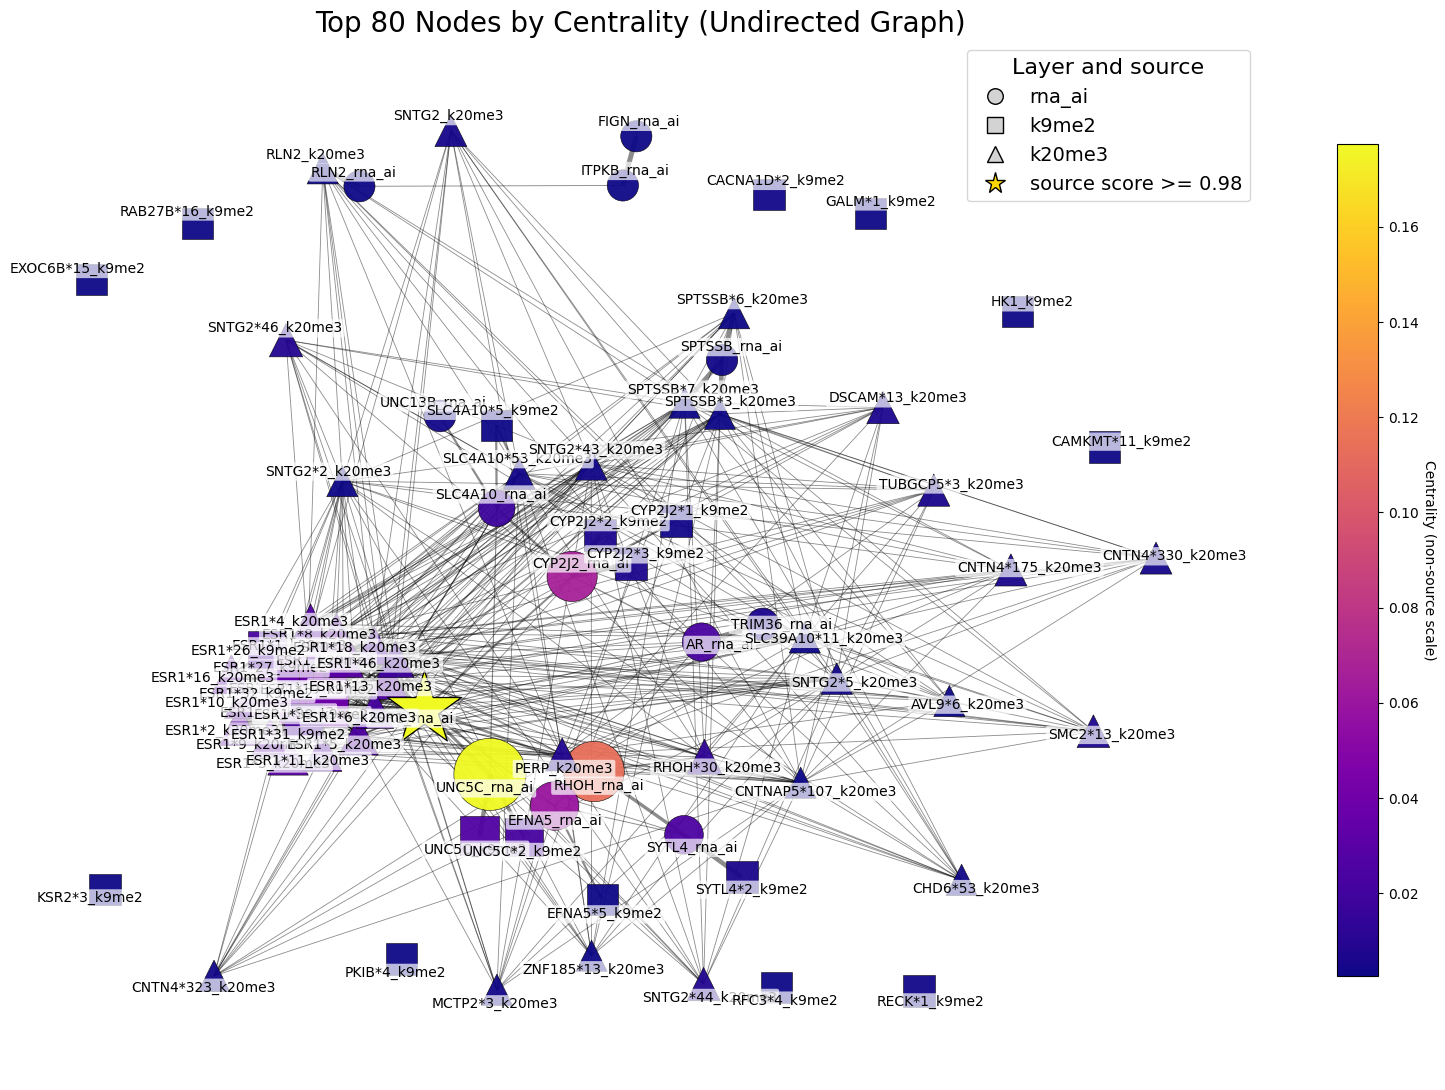

In [46]:
def visualize_top_centrality_networkx(
    adj_df,
    centrality,
    top_n=20,
    layout_seed=42,
    with_labels=True,
    figsize=(12, 9),
    cmap="plasma",
    layer_shape_map=None,
    source_tolerance=0.02,
    source_size_multiplier=1.05,
    save_path=None,
    label_mode="sources_and_top_n",
    label_top_n=80,
    label_font_size=8,
    title_font_size=16,
    label_offset=0.03,
    label_min_distance=0.09,
    label_box_alpha=0.70,
    legend_font_size=11,
    legend_title_font_size=13,
    legend_marker_scale=1.2,
):
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.lines import Line2D

    if layer_shape_map is None:
        layer_shape_map = {
            "rna_ai": "o",
            "k9me2": "s",
            "k20me3": "^",
            "k27me3": "D",
            "basis": "h",
            "other": "X",
        }

    def infer_layer(node_name):
        node = str(node_name)
        for layer in ["rna_ai", "k9me2", "k20me3", "k27me3"]:
            if node.endswith(f"_{layer}"):
                return layer
        if node in {"e1", "e2", "e3", "e4", "e5"}:
            return "basis"
        return "other"

    # Build an undirected view and keep the strongest weight per pair.
    G_directed = nx.from_pandas_adjacency(adj_df, create_using=nx.DiGraph)
    G = nx.Graph()
    for u, v, data in G_directed.edges(data=True):
        w = float(data.get("weight", 1.0))
        if G.has_edge(u, v):
            if abs(w) > abs(G[u][v].get("weight", 0.0)):
                G[u][v]["weight"] = w
        else:
            G.add_edge(u, v, weight=w)

    centrality_series = pd.Series(centrality, dtype=float).dropna()
    centrality_series = centrality_series[centrality_series.index.isin(G.nodes)]

    if centrality_series.empty:
        raise ValueError("No centrality nodes overlap with graph nodes.")

    top_nodes = centrality_series.sort_values(ascending=False).head(top_n).index.tolist()
    top_scores = centrality_series.loc[top_nodes]
    H = G.subgraph(top_nodes).copy()

    n_nodes = max(len(H.nodes), 1)
    pos = nx.spring_layout(H, seed=layout_seed, k=1.2 / np.sqrt(n_nodes))

    # Treat near-1 scores as source nodes and exclude them from normalization stats.
    source_threshold = 1.0 - float(source_tolerance)
    source_mask = top_scores >= source_threshold
    source_nodes = top_scores[source_mask].index.tolist()
    non_source_scores = top_scores[~source_mask]

    score_norm = pd.Series(0.5, index=top_scores.index, dtype=float)
    if non_source_scores.empty:
        smin = float(top_scores.min())
        smax = float(top_scores.max())
        color_norm = mcolors.Normalize(vmin=smin - 1e-9, vmax=smax + 1e-9)
    else:
        smin = float(non_source_scores.min())
        smax = float(non_source_scores.max())
        if np.isclose(smax, smin):
            score_norm.loc[~source_mask] = 0.5
            color_norm = mcolors.Normalize(vmin=smin - 1e-9, vmax=smax + 1e-9)
        else:
            score_norm.loc[~source_mask] = (non_source_scores - smin) / (smax - smin)
            color_norm = mcolors.Normalize(vmin=smin, vmax=smax)

    # Source nodes stay visually prominent but do not impact scaling of other nodes.
    score_norm.loc[source_mask] = 1.0

    node_sizes = pd.Series(500 + 2200 * score_norm.values, index=top_nodes)
    if source_mask.any():
        node_sizes.loc[source_mask] = node_sizes.loc[source_mask] * float(source_size_multiplier)

    node_layers = pd.Series([infer_layer(node) for node in top_nodes], index=top_nodes)

    edge_weights = np.array([abs(d.get("weight", 1.0)) for _, _, d in H.edges(data=True)], dtype=float)
    if edge_weights.size == 0:
        edge_widths = 1.0
    else:
        ew_min, ew_max = edge_weights.min(), edge_weights.max()
        if np.isclose(ew_max, ew_min):
            edge_widths = np.full(edge_weights.shape, 1.5)
        else:
            edge_widths = 0.6 + 3.0 * ((edge_weights - ew_min) / (ew_max - ew_min))

    fig, ax = plt.subplots(figsize=figsize)

    # Draw nodes by layer so each layer has a distinct marker shape.
    layers_in_plot = [layer for layer in layer_shape_map if layer in set(node_layers.values)]
    remaining_layers = [layer for layer in sorted(set(node_layers.values)) if layer not in layers_in_plot]
    layers_in_plot.extend(remaining_layers)

    for layer in layers_in_plot:
        layer_nodes = [n for n in node_layers[node_layers == layer].index.tolist() if n not in source_nodes]
        if not layer_nodes:
            continue

        nx.draw_networkx_nodes(
            H,
            pos,
            nodelist=layer_nodes,
            node_size=node_sizes.loc[layer_nodes].values,
            node_color=top_scores.loc[layer_nodes].values,
            cmap=cmap,
            vmin=color_norm.vmin,
            vmax=color_norm.vmax,
            node_shape=layer_shape_map.get(layer, "o"),
            edgecolors="black",
            linewidths=0.4,
            alpha=0.95,
            ax=ax,
        )

    nx.draw_networkx_edges(
        H,
        pos,
        width=edge_widths,
        alpha=0.45,
        arrows=False,
        connectionstyle="arc3",
        ax=ax,
    )

    if source_nodes:
        nx.draw_networkx_nodes(
            H,
            pos,
            nodelist=source_nodes,
            node_size=(1.10 * node_sizes.loc[source_nodes]).values,
            node_color=top_scores.loc[source_nodes].values,
            cmap=cmap,
            vmin=color_norm.vmin,
            vmax=color_norm.vmax,
            node_shape="*",
            edgecolors="black",
            linewidths=0.9,
            alpha=1.0,
            ax=ax,
        )

    if with_labels:
        valid_label_modes = {"all", "top_n", "sources_and_top_n"}
        if label_mode not in valid_label_modes:
            raise ValueError(f"label_mode must be one of {valid_label_modes}")

        ranked_nodes = top_scores.sort_values(ascending=False).index.tolist()
        top_label_nodes = ranked_nodes[: max(0, int(label_top_n))]
        source_nodes = top_scores[source_mask].index.tolist()

        if label_mode == "all":
            label_nodes = ranked_nodes
        elif label_mode == "top_n":
            label_nodes = top_label_nodes
        else:
            # Keep source labels and strongest labels, preserving order and uniqueness.
            label_nodes = list(dict.fromkeys(source_nodes + top_label_nodes))

        basis_label_nodes = {"e1", "e2", "e3", "e4", "e5"}
        label_nodes = [node for node in label_nodes if str(node) not in basis_label_nodes]

        if label_nodes:
            graph_center = np.mean(np.array(list(pos.values()), dtype=float), axis=0)
            label_positions = {node: np.array(pos[node], dtype=float).copy() for node in label_nodes}

            # Start labels slightly away from node centers in a radial direction.
            offset = float(label_offset)
            for node in label_nodes:
                direction = label_positions[node] - graph_center
                norm = np.linalg.norm(direction)
                if np.isclose(norm, 0.0):
                    direction = np.array([1.0, 0.0])
                    norm = 1.0
                label_positions[node] = label_positions[node] + offset * (direction / norm)

            # Simple pairwise repulsion to reduce label overlap.
            min_dist = float(label_min_distance)
            for _ in range(120):
                moved = False
                for i, node_i in enumerate(label_nodes):
                    for node_j in label_nodes[i + 1:]:
                        delta = label_positions[node_i] - label_positions[node_j]
                        dist = np.linalg.norm(delta)
                        if dist < min_dist:
                            if np.isclose(dist, 0.0):
                                delta = np.array([1.0, 0.0])
                                dist = 1.0
                            push = 0.5 * (min_dist - dist)
                            direction = delta / dist
                            label_positions[node_i] = label_positions[node_i] + direction * push
                            label_positions[node_j] = label_positions[node_j] - direction * push
                            moved = True
                if not moved:
                    break

            for node in label_nodes:
                x0, y0 = pos[node]
                x1, y1 = label_positions[node]
                ax.plot([x0, x1], [y0, y1], color="gray", linewidth=0.6, alpha=0.50, zorder=1)
                ax.text(
                    x1,
                    y1,
                    str(node),
                    fontsize=label_font_size,
                    ha="center",
                    va="center",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=label_box_alpha),
                    zorder=3,
                )

    sm = plt.cm.ScalarMappable(norm=color_norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
    cbar.set_label("Centrality (non-source scale)", rotation=270, labelpad=12)

    legend_layers = [layer for layer in layers_in_plot if layer != "basis"]
    shape_handles = [
        Line2D(
            [0],
            [0],
            marker=layer_shape_map.get(layer, "o"),
            color="none",
            markerfacecolor="lightgray",
            markeredgecolor="black",
            markersize=8,
            linestyle="",
            label=layer,
        )
        for layer in legend_layers
    ]

    if source_mask.any():
        shape_handles.append(
            Line2D(
                [0],
                [0],
                marker="*",
                color="none",
                markerfacecolor="gold",
                markeredgecolor="black",
                markersize=11,
                linestyle="",
                label=f"source score >= {source_threshold:.2f}",
            )
        )

    if shape_handles:
        ax.legend(
            handles=shape_handles,
            title="Layer and source",
            loc="best",
            fontsize=legend_font_size,
            title_fontsize=legend_title_font_size,
            markerscale=legend_marker_scale,
        )

    ax.set_title(
        f"Top {len(top_nodes)} Nodes by Centrality (Undirected Graph)",
        fontsize=title_font_size,
    )
    ax.axis("off")
    fig.tight_layout()

    if save_path:
        from pathlib import Path
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved network plot to: {save_path.resolve()}")
    plt.show()

    return H


# Example: visualize top nodes by a chosen centrality
graph_for_print = "spd"  # choose from: exp, gaussian, spd
centrality_for_print = local_scores  # choose from: pagerank, eigenvector, importance_scores, local_scores
start_node_for_print = str(local_center_node) if "local_center_node" in globals() else "unknown"
start_node_label_for_print = "".join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in start_node_for_print)

top20_nx_graph = visualize_top_centrality_networkx(
    adj_df=shadow_graphs[graph_for_print],
    centrality=centrality_for_print,
    top_n=80,
    figsize=(16, 11),
    cmap="plasma",
    source_tolerance=0.02,
    label_mode="sources_and_top_n",
    label_top_n=80,
    label_font_size=10,
    title_font_size=20,
    legend_font_size=14,
    legend_title_font_size=16,
    legend_marker_scale=1.4,
    label_min_distance=0.050,
    save_path=f"Paper_results/top_centrality_network_{graph_for_print}_start_{start_node_label_for_print}.png",
)

In [67]:
def cluster_comparison(
    single_graph,
    start,
    graph,
    r=0.7,
    rna_expression_df=None,
    histone_expression_df=None,
):
    """
    Matrix-based single-layer propagation from `start` on a histone graph,
    then map resulting histone-gene closeness scores to RNA genes and
    output RNA-expression-weighted gene closeness centrality.

    Also computes mean expression-time summaries for mapped histone genes
    and corresponding RNA genes.
    """
    import re

    if not isinstance(single_graph, pd.DataFrame):
        raise TypeError("single_graph must be a pandas DataFrame adjacency matrix")
    if start not in single_graph.index:
        raise ValueError(f"start node '{start}' not found in single_graph")
    if not 0.0 <= r <= 1.0:
        raise ValueError("r must be in [0, 1]")

    W = single_graph.astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    W = W.clip(lower=0.0)
    # Match multiplex normalization: each node's outgoing weights sum to 1.
    row_sums = W.sum(axis=1)
    W = W.div(row_sums.replace(0.0, np.nan), axis=0).fillna(0.0)

    nodes = list(W.index)
    n_nodes = len(nodes)
    start_idx = W.index.get_loc(start)

    # Closed-form propagation used in your original sketch:
    # R = (I - rA)^(-1), scores = R^T e_start
    A = W.to_numpy(dtype=float)
    Q = r * A
    I = np.eye(n_nodes)

    ei = np.zeros(n_nodes)
    ei[start_idx] = 1.0

    try:
        cluster_scores = np.linalg.solve((I - Q).T, ei)
    except np.linalg.LinAlgError:
        cluster_scores = np.linalg.pinv((I - Q).T) @ ei

    cluster_scores = np.clip(cluster_scores, a_min=0.0, a_max=None)
    histone_closeness_series = pd.Series(
        cluster_scores,
        index=nodes,
        name="histone_matrix_closeness",
    ).sort_values(ascending=False)

    def to_base_gene(node_name):
        name = str(node_name)
        for suffix in ("_k9me2", "_k20me3", "_k27me3", "_rna_ai"):
            if name.endswith(suffix):
                name = name[: -len(suffix)]
                break
        return name.split("*")[0]

    def infer_time_axis(columns):
        parsed = []
        for col in columns:
            col_str = str(col)
            try:
                parsed.append(float(col_str))
                continue
            except (TypeError, ValueError):
                pass

            matches = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", col_str)
            if matches:
                parsed.append(float(matches[-1]))
            else:
                return np.arange(len(columns), dtype=float)
        return np.array(parsed, dtype=float)

    def weighted_mean_time(expression_df):
        if not isinstance(expression_df, pd.DataFrame) or expression_df.empty:
            return pd.Series(dtype=float, name="mean_expression_time")

        time_axis = infer_time_axis(expression_df.columns)
        values = expression_df.to_numpy(dtype=float)
        values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
        weights = np.abs(values)

        denom = weights.sum(axis=1)
        numer = weights @ time_axis

        mean_time = np.full(expression_df.shape[0], np.nan, dtype=float)
        valid = denom > 0.0
        mean_time[valid] = numer[valid] / denom[valid]

        return pd.Series(mean_time, index=expression_df.index, name="mean_expression_time")

    basis_nodes = {"e1", "e2", "e3", "e4", "e5"}
    histone_scores_for_rna = histone_closeness_series[~histone_closeness_series.index.isin(basis_nodes)]

    if isinstance(graph, pd.DataFrame):
        rna_nodes = [str(n) for n in graph.index if str(n).endswith("_rna_ai")]
        available_rna_genes = {n[: -len("_rna_ai")] for n in rna_nodes}
    else:
        available_rna_genes = set()

    gene_map = pd.Series({node: to_base_gene(node) for node in histone_scores_for_rna.index})

    if available_rna_genes:
        keep_mask = gene_map.isin(available_rna_genes)
        gene_map = gene_map[keep_mask]
        histone_scores_for_rna = histone_scores_for_rna.loc[gene_map.index]

    if gene_map.empty:
        raise ValueError("No histone nodes could be mapped to RNA genes")

    # Important: mean is used only for RNA gene-level aggregation.
    # Raw histone_closeness_series remains unchanged for histone reporting/plotting.
    rna_from_histone = histone_scores_for_rna.groupby(gene_map).mean().rename("rna_gene_closeness_from_histone")

    if rna_expression_df is None and "datasets" in globals() and isinstance(datasets, dict) and "rna_ai" in datasets:
        rna_expression_df = datasets["rna_ai"]

    if isinstance(rna_expression_df, pd.DataFrame):
        rna_gene_index = pd.Index([to_base_gene(idx) for idx in rna_expression_df.index], name="gene")
        rna_expression_by_gene = rna_expression_df.groupby(rna_gene_index).mean()

        shared = rna_from_histone.index.intersection(rna_expression_by_gene.index)
        if len(shared) > 0:
            expr_strength = rna_expression_by_gene.loc[shared].abs().mean(axis=1).rename("rna_expression_mean_abs")
            if np.isclose(expr_strength.max(), expr_strength.min()):
                expr_norm = pd.Series(1.0, index=expr_strength.index)
            else:
                expr_norm = (expr_strength - expr_strength.min()) / (expr_strength.max() - expr_strength.min())

            rna_expr_closeness = (rna_from_histone.loc[shared] * (0.5 + 0.5 * expr_norm)).rename("rna_expression_gene_closeness")
            rna_result = pd.concat([rna_from_histone.loc[shared], expr_strength, rna_expr_closeness], axis=1)
        else:
            rna_result = rna_from_histone.to_frame()
            rna_result["rna_expression_gene_closeness"] = rna_result["rna_gene_closeness_from_histone"]
    else:
        rna_result = rna_from_histone.to_frame()
        rna_result["rna_expression_gene_closeness"] = rna_result["rna_gene_closeness_from_histone"]

    timing_result = pd.DataFrame(index=rna_result.index)

    if isinstance(histone_expression_df, pd.DataFrame):
        contributing_histone_nodes = gene_map.index
        available_histone_nodes = contributing_histone_nodes.intersection(histone_expression_df.index)

        if len(available_histone_nodes) > 0:
            histone_node_times = weighted_mean_time(histone_expression_df.loc[available_histone_nodes])
            histone_gene_map = gene_map.loc[available_histone_nodes]
            histone_gene_mean_time = histone_node_times.groupby(histone_gene_map).mean().rename("histone_mean_expression_time")
        else:
            histone_all_node_times = weighted_mean_time(histone_expression_df)
            histone_all_gene_index = pd.Index([to_base_gene(node) for node in histone_all_node_times.index], name="gene")
            histone_gene_mean_time = histone_all_node_times.groupby(histone_all_gene_index).mean().rename("histone_mean_expression_time")

        histone_gene_count = gene_map.value_counts().rename("histone_node_count")
        timing_result = timing_result.join(histone_gene_mean_time, how="left")
        timing_result = timing_result.join(histone_gene_count, how="left")

    if isinstance(rna_expression_df, pd.DataFrame):
        rna_node_times = weighted_mean_time(rna_expression_df)
        rna_gene_index_for_time = pd.Index([to_base_gene(node) for node in rna_node_times.index], name="gene")
        rna_gene_mean_time = rna_node_times.groupby(rna_gene_index_for_time).mean().rename("rna_mean_expression_time")

        rna_gene_count = pd.Series(rna_gene_index_for_time).value_counts().rename("rna_node_count")
        timing_result = timing_result.join(rna_gene_mean_time, how="left")
        timing_result = timing_result.join(rna_gene_count, how="left")

    if not timing_result.empty:
        rna_result = rna_result.join(timing_result, how="left")

    rna_result = rna_result.sort_values("rna_expression_gene_closeness", ascending=False)

    histone_display = histone_closeness_series.drop(index=start, errors="ignore")
    print("\nTop 20 histone-layer matrix closeness from start node (source removed):")
    print(histone_display.head(20).to_frame())

    rna_source_gene = to_base_gene(start)
    rna_display = rna_result.drop(index=rna_source_gene, errors="ignore")
    print("\nTop 20 RNA expression gene closeness centrality (source removed):")
    print(rna_display[["rna_expression_gene_closeness"]].head(20))

    if {"histone_mean_expression_time", "rna_mean_expression_time"}.issubset(rna_result.columns):
        print("\nTop 20 mean expression-time comparison (histone vs corresponding RNA):")
        print(rna_display[["histone_mean_expression_time", "rna_mean_expression_time"]].head(20))

    return histone_closeness_series, rna_result


def map_histone_scores_to_pca_nodes(histone_scores, histone_layer, node_to_coords):
    basis_nodes = {"e1", "e2", "e3", "e4", "e5"}
    mapped = {}

    for node, score in pd.Series(histone_scores, dtype=float).dropna().items():
        node_name = str(node)
        if node_name in basis_nodes:
            target_node = node_name
        elif node_name.endswith(f"_{histone_layer}"):
            target_node = node_name
        else:
            target_node = f"{node_name}_{histone_layer}"

        if target_node in node_to_coords:
            mapped[target_node] = float(score)

    return pd.Series(mapped, name="histone_matrix_closeness_on_pca_nodes").sort_values(ascending=False)


def map_rna_gene_scores_to_pca_nodes(rna_gene_scores, rna_expression_df, node_to_coords):
    mapped = {}
    clean_scores = pd.Series(rna_gene_scores, dtype=float).dropna()

    for rna_node in rna_expression_df.index:
        rna_node_name = str(rna_node)
        if rna_node_name.endswith("_rna_ai"):
            base_gene = rna_node_name[: -len("_rna_ai")].split("*")[0]
            target_node = rna_node_name
        else:
            base_gene = rna_node_name.split("*")[0]
            target_node = f"{rna_node_name}_rna_ai"

        if base_gene not in clean_scores.index:
            continue

        if target_node in node_to_coords:
            mapped[target_node] = float(clean_scores.loc[base_gene])

    return pd.Series(mapped, name="rna_expression_gene_closeness_on_pca_nodes").sort_values(ascending=False)


# Example: histone-layer matrix propagation to RNA-expression gene closeness
histone_layer_for_cluster = "k27me3"  # choose: k9me2, k20me3, k27me3
single_histone_graph = single_layer_graphs_gaussian[histone_layer_for_cluster]
opt = "guassian"

non_basis_nodes = [n for n in single_histone_graph.index if n not in {"e1", "e2", "e3", "e4", "e5"}]
if not non_basis_nodes:
    raise ValueError("Selected single histone graph has no non-basis gene nodes")

start_histone_node = "CDCA7*8"


histone_rw_closeness, rna_gene_closeness_df = cluster_comparison(
    single_graph=single_histone_graph,
    start=start_histone_node,
    graph=shadow_graphs["gaussian"],
    r=0.7,
    rna_expression_df=datasets["rna_ai"],
    histone_expression_df=datasets[histone_layer_for_cluster],
)
rna_source_gene = str(start_histone_node).split("*")[0]
rna_gene_closeness_no_source = rna_gene_closeness_df.drop(index=rna_source_gene, errors="ignore")

if "pca_model" not in globals() or "node_to_coords" not in globals():
    pca_model, node_to_coords = build_pca_projection_map(datasets, keys)

# Build per-layer scores for a single combined PCA plot (histone + RNA).
histone_rw_closeness_no_source = histone_rw_closeness.drop(index=start_histone_node, errors="ignore")
histone_plot_scores = map_histone_scores_to_pca_nodes(
    histone_scores=histone_rw_closeness_no_source,
    histone_layer=histone_layer_for_cluster,
    node_to_coords=node_to_coords,
)

# RNA gene-level result by assigning each RNA node its base-gene closeness score.
rna_plot_scores = map_rna_gene_scores_to_pca_nodes(
    rna_gene_scores=rna_gene_closeness_no_source["rna_expression_gene_closeness"],
    rna_expression_df=datasets["rna_ai"],
    node_to_coords=node_to_coords,
)

from pathlib import Path
histone_start_label = "".join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(start_histone_node))
combined_plot_scores = pd.concat([histone_plot_scores, rna_plot_scores], axis=0)

if combined_plot_scores.empty:
    print("No histone or RNA nodes could be mapped onto PCA coordinates for combined plotting.")
else:
    if combined_plot_scores.index.has_duplicates:
        combined_plot_scores = combined_plot_scores.groupby(level=0).max()
    combined_plot_scores = combined_plot_scores.sort_values(ascending=False)

    fig_cluster_combined = plot_node_scores_on_pca(
        score_series=combined_plot_scores,
        node_to_coords=node_to_coords,
        pca_model=pca_model,
        keys=keys,
        title=(
            f"Histone + RNA Cluster Regulation Plot "
            f"[{histone_layer_for_cluster} | start={start_histone_node}]"
        ),
    )

    output_file_cluster_combined = Path("Paper_results") / (
        f"pca_cluster_histone_rna_combined_{histone_layer_for_cluster}_{histone_start_label}.html"
    )
    output_file_cluster_combined.parent.mkdir(parents=True, exist_ok=True)
    fig_cluster_combined.write_html(output_file_cluster_combined, include_plotlyjs="cdn")
    print(f"Saved interactive plot to: {output_file_cluster_combined.resolve()}")

summary_cols = [
    "rna_gene_closeness_from_histone",
    "rna_expression_mean_abs",
    "rna_expression_gene_closeness",
    "histone_mean_expression_time",
    "rna_mean_expression_time",
    "histone_node_count",
    "rna_node_count",
]
summary_cols = [c for c in summary_cols if c in rna_gene_closeness_no_source.columns]
rna_gene_closeness_no_source[summary_cols].head(20)


Top 20 histone-layer matrix closeness from start node (source removed):
            histone_matrix_closeness
FBXO32*1                    0.010261
SYTL4*3                     0.010243
THSD4*6                     0.010210
PDZD2*30                    0.010147
TPM1*5                      0.010102
TMEM164*28                  0.010022
HADH*1                      0.010020
AK4*8                       0.010000
RABGAP1L*9                  0.009993
MACROD2*34                  0.009973
PXDNL*1                     0.009970
STXBP6*7                    0.009934
PRKCE*7                     0.009886
OXER1*10                    0.009882
DMD*43                      0.009878
MAT1A*3                     0.009868
TBC1D2*12                   0.009853
MRPL3*20                    0.009844
HK1*8                       0.009815
STXBP6*12                   0.009783

Top 20 RNA expression gene closeness centrality (source removed):
          rna_expression_gene_closeness
ADGRA3                         0.009069
RAB

Saved interactive plot to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\pca_cluster_histone_rna_combined_k27me3_CDCA7_8.html


,rna_gene_closeness_from_histone,rna_expression_mean_abs,rna_expression_gene_closeness,histone_mean_expression_time,rna_mean_expression_time,histone_node_count,rna_node_count
ADGRA3,0.009351,0.849761,0.009069,2.012760,1.710986,1,1
RABGAP1L,0.009993,0.814158,0.009017,1.990449,2.191278,1,1
SYTL4,0.010004,0.777183,0.008326,1.958182,2.369459,2,1
UNC13B,0.008485,0.837885,0.008038,2.008811,2.261417,2,1
VSTM2L,0.008196,0.814446,0.007400,1.899505,2.085260,3,1
TPM1,0.009032,0.757613,0.007182,1.918446,2.365849,4,1
MACROD2,0.009410,0.740522,0.007177,2.028153,2.231220,2,1
TTC6,0.007805,0.807904,0.006950,1.980209,2.128795,1,1
HADH,0.010020,0.694075,0.006761,2.011776,1.049521,1,1
OXER1,0.009362,0.708355,0.006570,1.896252,1.254154,2,1


In [69]:
import re
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.colors import qualitative


def to_base_gene_name(node_name):
    name = str(node_name)
    for suffix in ("_k9me2", "_k20me3", "_k27me3", "_rna_ai"):
        if name.endswith(suffix):
            name = name[: -len(suffix)]
            break
    return name.split("*")[0]


def infer_time_axis_from_columns(columns):
    parsed = []
    for col in columns:
        col_str = str(col)
        try:
            parsed.append(float(col_str))
            continue
        except (TypeError, ValueError):
            pass

        matches = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", col_str)
        if matches:
            parsed.append(float(matches[-1]))
        else:
            return np.arange(len(columns), dtype=float)

    return np.array(parsed, dtype=float)


def trajectories_per_gene(expression_df):
    if not isinstance(expression_df, pd.DataFrame) or expression_df.empty:
        raise ValueError("expression_df must be a non-empty pandas DataFrame")

    gene_index = pd.Index([to_base_gene_name(idx) for idx in expression_df.index], name="gene")
    return expression_df.groupby(gene_index).mean()


def plot_top_n_histone_rna_trajectories(
    ranked_genes_df,
    histone_expression_df,
    rna_expression_df,
    top_n=20,
    score_col="rna_expression_gene_closeness",
    title=None,
):
    if not isinstance(ranked_genes_df, pd.DataFrame) or ranked_genes_df.empty:
        raise ValueError("ranked_genes_df must be a non-empty pandas DataFrame")
    if top_n <= 0:
        raise ValueError("top_n must be a positive integer")

    if score_col not in ranked_genes_df.columns:
        numeric_cols = ranked_genes_df.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            raise ValueError(f"Column '{score_col}' not found and no numeric fallback column is available")
        score_col = numeric_cols[0]

    ranked_scores = pd.Series(ranked_genes_df[score_col], dtype=float).dropna().sort_values(ascending=False)
    top_genes = ranked_scores.head(int(top_n)).index.astype(str).tolist()

    histone_gene_traj = trajectories_per_gene(histone_expression_df)
    rna_gene_traj = trajectories_per_gene(rna_expression_df)

    shared_genes = [g for g in top_genes if g in histone_gene_traj.index and g in rna_gene_traj.index]
    if not shared_genes:
        raise ValueError("No overlapping top genes between histone and RNA expression datasets")

    histone_top = histone_gene_traj.loc[shared_genes]
    rna_top = rna_gene_traj.loc[shared_genes]

    x_histone = infer_time_axis_from_columns(histone_top.columns)
    x_rna = infer_time_axis_from_columns(rna_top.columns)

    palette = (
        qualitative.Alphabet
        + qualitative.Dark24
        + qualitative.Plotly
        + qualitative.Set3
    )

    fig = go.Figure()
    for i, gene in enumerate(shared_genes):
        color = palette[i % len(palette)]

        fig.add_trace(
            go.Scatter(
                x=x_histone,
                y=histone_top.loc[gene].to_numpy(dtype=float),
                mode="lines+markers",
                name=f"{gene} | histone",
                legendgroup=str(gene),
                line=dict(color=color, width=2, dash="dash"),
                marker=dict(size=5),
                opacity=0.8,
                hovertemplate=(
                    "Gene: " + str(gene) + "<br>Layer: histone"
                    + "<br>Time: %{x}<br>Expression: %{y:.4f}<extra></extra>"
                ),
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_rna,
                y=rna_top.loc[gene].to_numpy(dtype=float),
                mode="lines+markers",
                name=f"{gene} | RNA",
                legendgroup=str(gene),
                line=dict(color=color, width=2),
                marker=dict(size=5),
                opacity=0.8,
                hovertemplate=(
                    "Gene: " + str(gene) + "<br>Layer: RNA"
                    + "<br>Time: %{x}<br>Expression: %{y:.4f}<extra></extra>"
                ),
            )
        )

    fig.update_layout(
    title=dict(
        text=title or f"Top {len(shared_genes)} Histone and RNA Trajectories",
        font=dict(size=28),
    ),
    xaxis_title="Time",
    yaxis_title="Standardized expression",
    xaxis=dict(title_font=dict(size=24), tickfont=dict(size=16)),
    yaxis=dict(title_font=dict(size=24), tickfont=dict(size=16)),
    template="plotly_white",
    width=1200,
    height=700,
    legend_title=dict(text="Gene and layer", font=dict(size=20)),
    legend=dict(font=dict(size=20)),
)
    fig.show()
    output_file_png = output_file_top_traj.with_suffix(".png")
    fig.write_image(output_file_png, scale=4, width=1200, height=700)
    print(f"Saved high-quality PNG to: {output_file_png.resolve()}")

    return fig, shared_genes, histone_top, rna_top


# Example usage on current cluster_comparison output
top_n_trajectories = 20
fig_top_n_all, shared_top_genes, histone_top_traj, rna_top_traj = plot_top_n_histone_rna_trajectories(
    ranked_genes_df=rna_gene_closeness_no_source,
    histone_expression_df=datasets[histone_layer_for_cluster],
    rna_expression_df=datasets["rna_ai"],
    top_n=top_n_trajectories,
    score_col="rna_expression_gene_closeness",
    title=(
        f"Top {top_n_trajectories} trajectories "
        f"[{histone_layer_for_cluster} histone and RNA]"
    ),
)

from pathlib import Path
traj_start_label = str(globals().get("histone_start_label", ""))
if not traj_start_label:
    traj_start_raw = str(globals().get("start_histone_node", "unknown"))
    traj_start_label = "".join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in traj_start_raw)
output_file_top_traj = Path("Paper_results") / (
    f"top_{top_n_trajectories}_histone_rna_trajectories_{histone_layer_for_cluster}_{traj_start_label}_{opt}.html"
)
output_file_top_traj.parent.mkdir(parents=True, exist_ok=True)
fig_top_n_all.write_html(output_file_top_traj, include_plotlyjs="cdn")
print(f"Saved interactive plot to: {output_file_top_traj.resolve()}")

print(f"Shared genes plotted: {len(shared_top_genes)}")
print(shared_top_genes[:10])

pd.concat(
    [
        histone_top_traj.add_prefix("histone_"),
        rna_top_traj.add_prefix("rna_"),
    ],
    axis=1,
).head()

Saved high-quality PNG to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\top_20_histone_rna_trajectories_k27me3_CDCA7_8_guassian.png
Saved interactive plot to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\top_20_histone_rna_trajectories_k27me3_CDCA7_8_guassian.html
Shared genes plotted: 20
['ADGRA3', 'RABGAP1L', 'SYTL4', 'UNC13B', 'VSTM2L', 'TPM1', 'MACROD2', 'TTC6', 'HADH', 'OXER1']


,histone_0,histone_1,histone_2,histone_3,histone_4,rna_0,rna_1,rna_2,rna_3,rna_4
gene,,,,,,,,,,
ADGRA3,-0.495730,-0.330620,1.782833,-0.545387,-0.411097,1.263738,0.860664,-0.852123,-0.384384,-0.887896
RABGAP1L,-0.546252,-0.324458,1.783158,-0.441996,-0.470452,0.321933,-1.027548,1.279089,0.434373,-1.007847
SYTL4,-0.560814,-0.319671,1.780568,-0.507799,-0.392285,0.060892,-0.867982,-1.074975,1.338678,0.543387
UNC13B,-0.558317,-0.297538,1.777668,-0.398159,-0.523654,-0.899943,-0.621994,-0.572777,0.672361,1.422352
VSTM2L,-0.607355,-0.360919,1.777660,-0.400538,-0.408847,-0.672985,0.525981,1.510134,-0.507109,-0.856021


In [ ]:
import re
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.colors import qualitative
from pathlib import Path

# Deduplicated gene node names (dataset suffix stripped, *locus kept)
gene_node_names = [
    "SHOX2",
    "FMNL2*2",
    "TMEM164",
    "DNAH14",
    "SGMS1",
    "FHOD3",
    "FHOD3*48",
    "GRIK2",
    "HK1",
    "AR*5",
    "TRIM37",
    "SEMA5A*70",
    "CDKN3",
]

dataset_style = {
    "rna_ai":  dict(dash="solid",   symbol="circle"),
    "k20me3":  dict(dash="dash",    symbol="square"),
    "k9me2":   dict(dash="dot",     symbol="diamond"),
    "k27me3":  dict(dash="dashdot", symbol="cross"),
}

palette = (
    qualitative.Alphabet + qualitative.Dark24 + qualitative.Plotly + qualitative.Set3
)


def _infer_time_axis(columns):
    parsed = []
    for col in columns:
        col_str = str(col)
        try:
            parsed.append(float(col_str))
            continue
        except (TypeError, ValueError):
            pass
        m = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", col_str)
        parsed.append(float(m[-1]) if m else float(len(parsed)))
    return np.array(parsed, dtype=float)


def _base_gene(name):
    """Return the gene name before any '*locus' suffix."""
    return name.split("*")[0]


# Assign one colour per unique base gene name, in order of first appearance
_base_names_ordered = list(dict.fromkeys(_base_gene(g) for g in gene_node_names))
_base_gene_color = {base: palette[i % len(palette)] for i, base in enumerate(_base_names_ordered)}

fig = go.Figure()
_shown_group_titles = set()

for gene in gene_node_names:
    base = _base_gene(gene)
    color = _base_gene_color[base]
    for ds_name, ds_df in datasets.items():
        if gene not in ds_df.index:
            continue
        style = dataset_style.get(ds_name, dict(dash="solid", symbol="circle"))
        x = _infer_time_axis(ds_df.columns)
        y = ds_df.loc[gene].to_numpy(dtype=float)
        title_text = base if base not in _shown_group_titles else None
        if title_text:
            _shown_group_titles.add(base)
        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="lines+markers",
                name=f"{gene} | {ds_name}",
                legendgroup=base,
                legendgrouptitle_text=title_text,
                line=dict(color=color, width=2, dash=style["dash"]),
                marker=dict(size=6, symbol=style["symbol"]),
                opacity=0.85,
                hovertemplate=(
                    f"Gene: {gene}<br>Dataset: {ds_name}"
                    "<br>Time: %{x}<br>Expression: %{y:.4f}<extra></extra>"
                ),
            )
        )

fig.update_layout(
    title="Top-ranked gene trajectories across all datasets with respect to PageRank centrality",
    xaxis_title="Time point",
    yaxis_title="Standardized expression",
    template="plotly_white",
    width=1300,
    height=750,
    legend_title="Gene | Dataset",
)
fig.show()

output_file = Path("Paper_results") / "top_ranked_genes_all_datasets_trajectories_Pagerank.html"
output_file.parent.mkdir(parents=True, exist_ok=True)
fig.write_html(output_file, include_plotlyjs="cdn")
print(f"Saved to: {output_file.resolve()}")

# Report which genes were found / missing per dataset
print("\nCoverage summary:")
for gene in gene_node_names:
    found = [ds for ds, df in datasets.items() if gene in df.index]
    missing = [ds for ds in datasets if ds not in found]
    print(f"  {gene:20s}  found: {found}  missing: {missing}")


Saved to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\top_ranked_genes_all_datasets_trajectories.html

Coverage summary:
  SHOX2                 found: ['k20me3', 'rna_ai']  missing: ['k27me3', 'k9me2']
  FMNL2*2               found: ['k20me3', 'k9me2']  missing: ['k27me3', 'rna_ai']
  TMEM164               found: ['k9me2', 'rna_ai']  missing: ['k20me3', 'k27me3']
  DNAH14                found: ['rna_ai']  missing: ['k20me3', 'k27me3', 'k9me2']
  SGMS1                 found: ['rna_ai']  missing: ['k20me3', 'k27me3', 'k9me2']
  FHOD3                 found: ['rna_ai']  missing: ['k20me3', 'k27me3', 'k9me2']
  FHOD3*48              found: ['k20me3']  missing: ['k27me3', 'k9me2', 'rna_ai']
  GRIK2                 found: ['rna_ai']  missing: ['k20me3', 'k27me3', 'k9me2']
  HK1                   found: ['k27me3', 'k9me2', 'rna_ai']  missing: ['k20me3']
  AR*5                  found: ['k20me3']  missing: ['k27me3', 'k9me2', 'rn

In [ ]:
# Start-to-end top-ranked gene trajectories across all datasets
# Deduplicated node names (dataset suffix stripped, *locus kept)
start_to_end_gene_nodes = [
    "FST*18",
    "GPX3*1",
    "GPX3",
    "ADAMTS19*1",
    "FST*21",
    "AKAP1*43",
    "FST*10",
    "HK1",
    "HK1*9",
    "TPM1",
    "PRKCE*9",
    "AVL9*1",
]

# Assign one colour per unique base gene name, in order of first appearance
_ste_base_names_ordered = list(dict.fromkeys(_base_gene(g) for g in start_to_end_gene_nodes))
_ste_base_gene_color = {base: palette[i % len(palette)] for i, base in enumerate(_ste_base_names_ordered)}

fig_ste = go.Figure()
_ste_shown_titles = set()

for gene in start_to_end_gene_nodes:
    base = _base_gene(gene)
    color = _ste_base_gene_color[base]
    for ds_name, ds_df in datasets.items():
        if gene not in ds_df.index:
            continue
        style = dataset_style.get(ds_name, dict(dash="solid", symbol="circle"))
        x = _infer_time_axis(ds_df.columns)
        y = ds_df.loc[gene].to_numpy(dtype=float)
        title_text = base if base not in _ste_shown_titles else None
        if title_text:
            _ste_shown_titles.add(base)
        fig_ste.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="lines+markers",
                name=f"{gene} | {ds_name}",
                legendgroup=base,
                legendgrouptitle_text=title_text,
                line=dict(color=color, width=2, dash=style["dash"]),
                marker=dict(size=6, symbol=style["symbol"]),
                opacity=0.85,
                hovertemplate=(
                    f"Gene: {gene}<br>Dataset: {ds_name}"
                    "<br>Time: %{x}<br>Expression: %{y:.4f}<extra></extra>"
                ),
            )
        )

fig_ste.update_layout(
    title="Top-ranked gene trajectories across all datasets with respect to start-to-end path importance",
    xaxis_title="Time point",
    yaxis_title="Standardized expression",
    template="plotly_white",
    width=1300,
    height=750,
    legend_title="Gene | Dataset",
)
fig_ste.show()

output_file_ste = Path("Paper_results") / "top_ranked_genes_all_datasets_trajectories_start_to_end.html"
output_file_ste.parent.mkdir(parents=True, exist_ok=True)
fig_ste.write_html(output_file_ste, include_plotlyjs="cdn")
print(f"Saved to: {output_file_ste.resolve()}")

print("\nCoverage summary:")
for gene in start_to_end_gene_nodes:
    found = [ds for ds, df in datasets.items() if gene in df.index]
    missing = [ds for ds in datasets if ds not in found]
    print(f"  {gene:20s}  found: {found}  missing: {missing}")


Saved to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\top_ranked_genes_all_datasets_trajectories_start_to_end.html

Coverage summary:
  FST*18                found: ['k27me3']  missing: ['k20me3', 'k9me2', 'rna_ai']
  GPX3*1                found: ['k27me3', 'k9me2']  missing: ['k20me3', 'rna_ai']
  GPX3                  found: ['rna_ai']  missing: ['k20me3', 'k27me3', 'k9me2']
  ADAMTS19*1            found: ['k20me3', 'k9me2']  missing: ['k27me3', 'rna_ai']
  FST*21                found: ['k20me3']  missing: ['k27me3', 'k9me2', 'rna_ai']
  AKAP1*43              found: ['k20me3']  missing: ['k27me3', 'k9me2', 'rna_ai']
  FST*10                found: ['k9me2']  missing: ['k20me3', 'k27me3', 'rna_ai']
  HK1                   found: ['k27me3', 'k9me2', 'rna_ai']  missing: ['k20me3']
  HK1*9                 found: ['k27me3']  missing: ['k20me3', 'k9me2', 'rna_ai']
  TPM1                  found: ['rna_ai']  missing: ['k20me3',